# Aula 3 - Visualização de Dados

In [ ]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Senior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Senior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Junior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


<Axes: title={'center': 'distribuição de senioridade'}, xlabel='senioridade'>

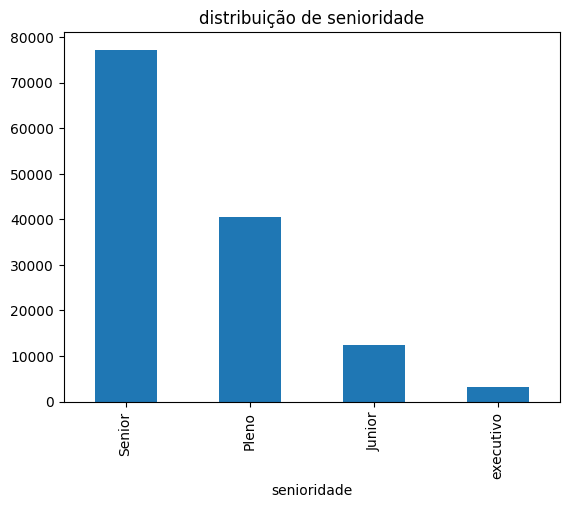

In [ ]:
df_limpo['senioridade'].value_counts().plot(kind='bar', title='distribuição de senioridade')

In [ ]:
import seaborn as sns

<Axes: xlabel='senioridade', ylabel='usd'>

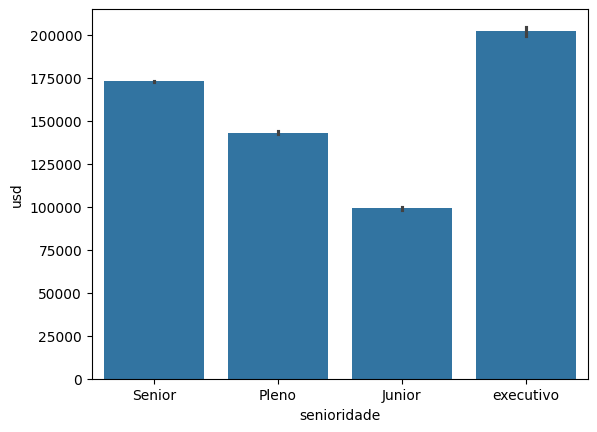

In [ ]:
sns.barplot(data=df_limpo, x='senioridade', y='usd')

In [ ]:
import matplotlib.pyplot as plt

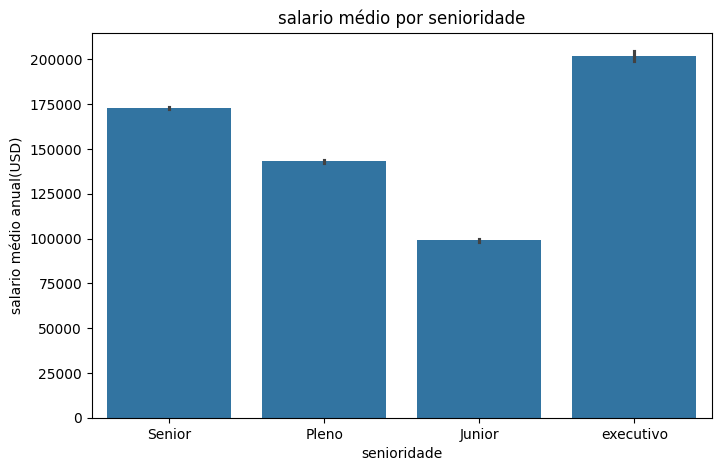

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senioridade', y='usd')
plt.title('salario médio por senioridade')
plt.xlabel('senioridade')
plt.ylabel('salario médio anual(USD)')
plt.show()

In [ ]:
df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False)

,usd
senioridade,
executivo,202027.667813
Senior,172850.838301
Pleno,143044.845979
Junior,99034.963267


In [ ]:
ordem = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=True).index

In [ ]:
ordem

Index(['Junior', 'Pleno', 'Senior', 'executivo'], dtype='object', name='senioridade')

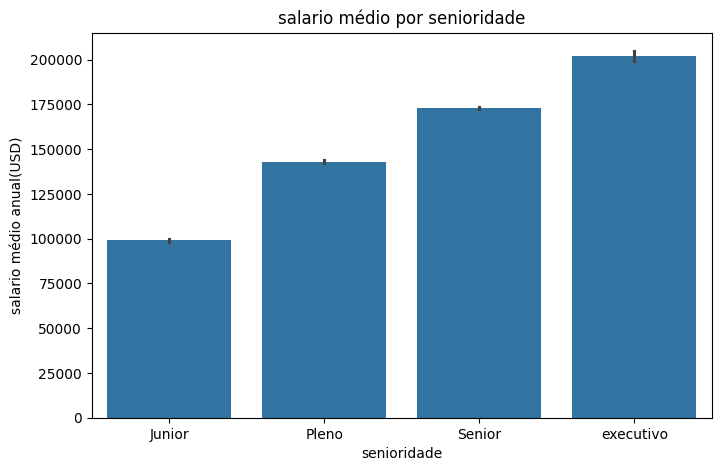

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senioridade', y='usd', order=ordem)
plt.title('salario médio por senioridade')
plt.xlabel('senioridade')
plt.ylabel('salario médio anual(USD)')
plt.show()

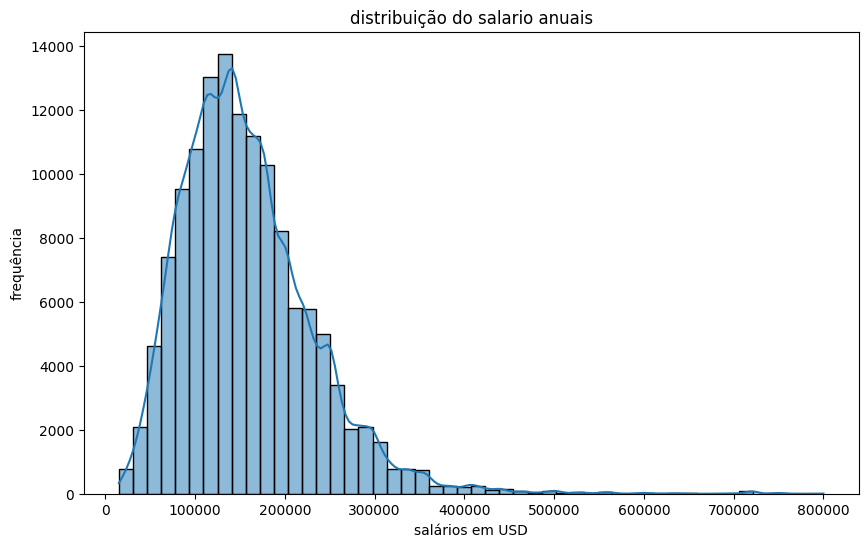

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_limpo['usd'],bins = 50, kde=True)
plt.title('distribuição do salario anuais')
plt.xlabel('salários em USD')
plt.ylabel('frequência')
plt.show()

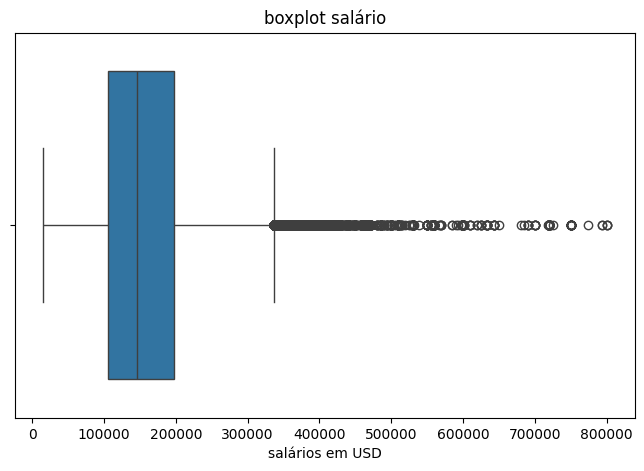

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_limpo['usd'])
plt.title('boxplot salário')
plt.xlabel('salários em USD')
plt.show()

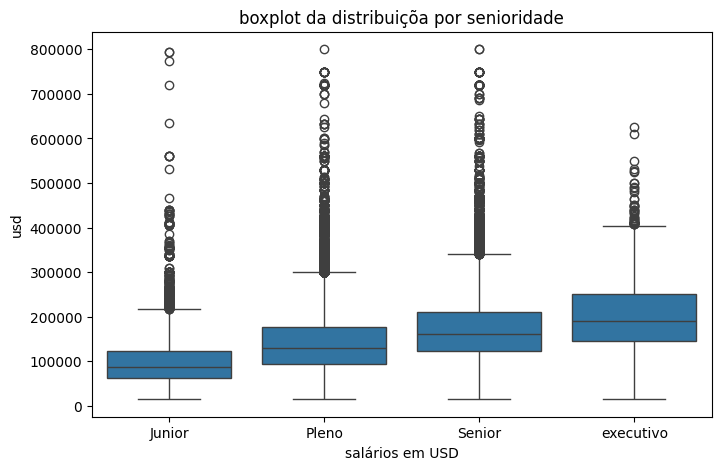

In [ ]:
ordem_senioridade = ['Junior', 'Pleno', 'Senior', 'executivo']

plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade)
plt.title('boxplot da distribuiçõa por senioridade')
plt.xlabel('salários em USD')
plt.show()

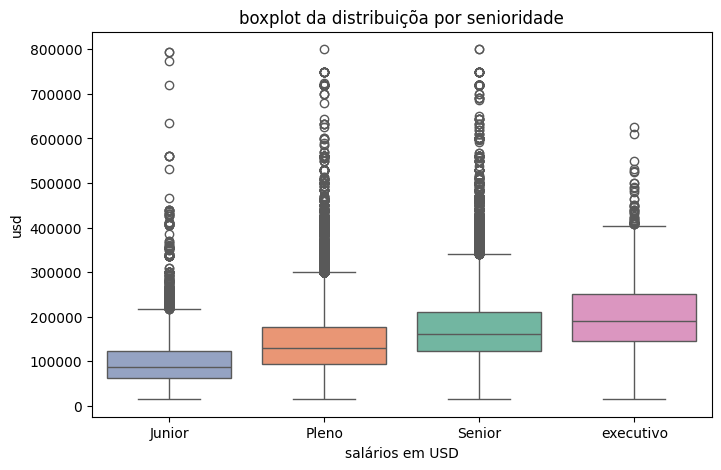

In [ ]:
ordem_senioridade = ['Junior', 'Pleno', 'Senior', 'executivo']

plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade, palette='Set2', hue='senioridade')
plt.title('boxplot da distribuiçõa por senioridade')
plt.xlabel('salários em USD')
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
df_senioridade_usd = df_limpo.groupby('senioridade')['usd'].mean().reset_index()

new_ordem = df_senioridade_usd.sort_values(by='usd', ascending=False)['senioridade'].tolist()

fig = px.bar(
    df_senioridade_usd,
    x='senioridade',
    y='usd',
    title='Média Salarial por Senioridade (USD)',
    labels={'senioridade': 'Senioridade', 'usd': 'Média Salarial Anual (USD)'},
    category_orders={'senioridade': new_ordem}
)

fig.update_layout(xaxis_title='Senioridade', yaxis_title='Média Salarial Anual (USD)')
fig.show()

In [ ]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
    names='tipo_trabalho',
    values='quantidade',
    title='proporção dos tipos de trabalho'
)

fig.show()

In [ ]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
    names='tipo_trabalho',
    values='quantidade',
    title='proporção dos tipos de trabalho',
    hole=0.5
)

fig.show()

In [ ]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
    names='tipo_trabalho',
    values='quantidade',
    title='proporção dos tipos de trabalho',
    hole=0.5
)
fig.update_traces(textinfo='percent+label')
fig.show()

In [ ]:
df_data_scientist = df_limpo[df_limpo['cargo'] == 'Data Scientist']

salario_por_pais_ds = df_data_scientist.groupby('empresa')['usd'].mean().reset_index()

# Ordenar os países pelo salário médio em ordem decrescente
salario_por_pais_ds = salario_por_pais_ds.sort_values(by='usd', ascending=False)

fig = px.bar(
    salario_por_pais_ds,
    x='empresa',
    y='usd',
    color='empresa', # Cores diferentes para cada país
    title='Salário Médio de Data Scientists por País (USD)',
    labels={'empresa': 'País da Empresa', 'usd': 'Salário Médio Anual (USD)'},
    template='plotly_dark' # Aplica o tema escuro e moderno
)

fig.update_layout(xaxis_title='País da Empresa', yaxis_title='Salário Médio Anual (USD)')
fig.show()